# Exercise 3: June 11, 2025

# Importing Data and Plotting

**Question 1.** Let's practice making some basic plots. First, plot $y=\sin{(x)}\exp{(-x/4)}$ for $x=0,4\pi$. This will create a sine wave damped by the exponential decay function.  

In [ ]:
import numpy as np

In [ ]:
import matplotlib.pyplot as plt

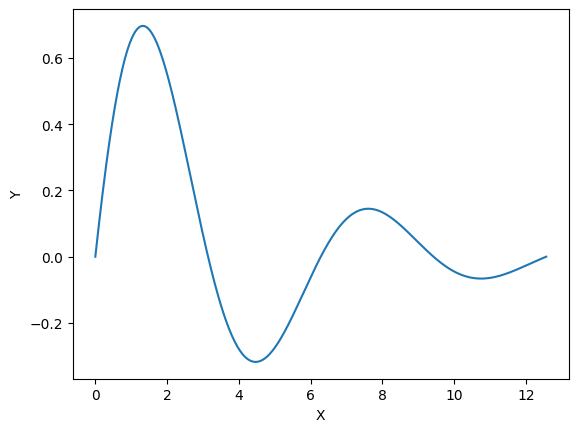

In [ ]:
x = np.linspace(0, 4*np.pi, 500)
y = np.sin(x)*np.exp(-x/4)

plt.plot(x,y)
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

**Question 2.** Now plot $\sin{x}$, $\cos{x}$, and $\sin{(x)}\cos{(x)}$ on the same graph. Include a legend.

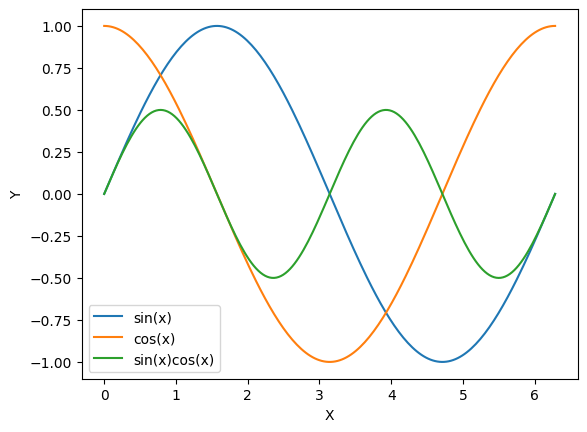

In [ ]:
x = np.linspace(0, 2*np.pi, 200)
y_sin = np.sin(x)
y_cos = np.cos(x)
y_sc = np.sin(x)*np.cos(x)

plt.plot(x,y_sin, x,y_cos, x,y_sc)
plt.xlabel("X")
plt.ylabel("Y")
plt.legend(["sin(x)", "cos(x)", "sin(x)cos(x)"])
plt.show()

# Plotting Topographic Data

**Question 3.** Import the topo.dat data file using numpy. The file contains elevation data for the Earth, in the format: column 1- latitude; column 2- longitude; column 3- elevation. Plot two scatter plots: elevation as a function of latitude and elevation as a function of longitude.   

In [ ]:
from google.colab import files
files.upload()
Elevation_Data = np.loadtxt('topo.dat',usecols=(0,1,2), unpack=True)

Saving topo.dat to topo (1).dat


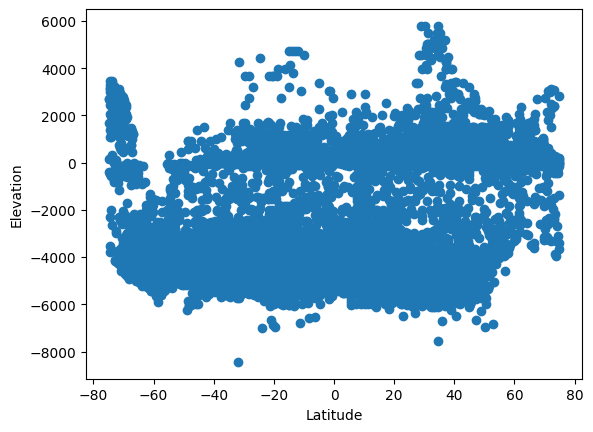

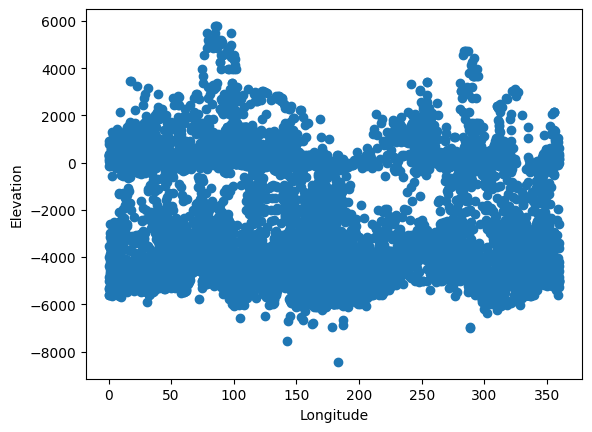

In [ ]:
latitude = Elevation_Data[0]
longitude = Elevation_Data[1]
elevation = Elevation_Data[2]
plt.scatter(latitude, elevation)
plt.xlabel("Latitude")
plt.ylabel("Elevation")
plt.show()

plt.scatter(longitude, elevation)
plt.xlabel("Longitude")
plt.ylabel("Elevation")
plt.show()

**Question 4.** Now make a more attractive version of these plots, where you color the markers based on their elevation. Try different colormaps until you find one that you think shows the data well.

Looking at a map, can you identify some of the features in this elevation data (as in specific mountain ranges or undersea features)?

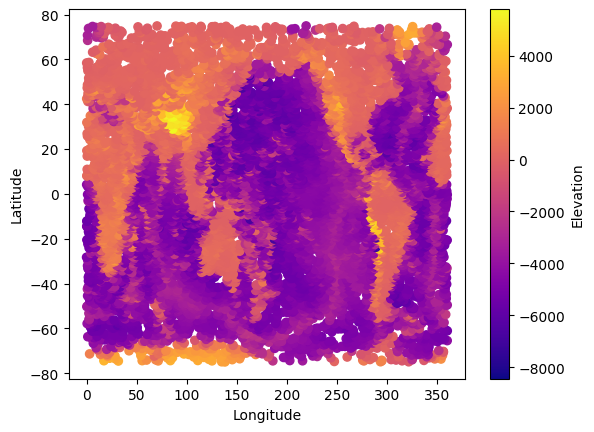

In [ ]:
plt.scatter(longitude, latitude, s=35, c=elevation, cmap="plasma", edgecolor=None)
plt.xlabel("Longitude")
plt.ylabel("Latitude")

cb=plt.colorbar()
cb.set_label(label="Elevation")

**I believe I can descern some of the features on the map. I believe the higher elevation features are continents, with Asia, Europe, Africa, and Australia to the left; the Americas to the right; and Antarctica at the bottom. I can also see some mountain ranges present where the highest elevation is in the Himalayas and Andes, as well as along the western coast of North America.**

**Question 5.** Convert the elevation data from meters to feet. The plot the data as a histogram. Experiment with changing the number of bins until the histogram looks like a good representation of the data. What do you see in the historgram? How many peaks, and what do these peaks represent?  

[  8799.21259843  -1364.82939633   8799.21259843 ...    498.68766404
   -216.53543307 -11945.53805774]


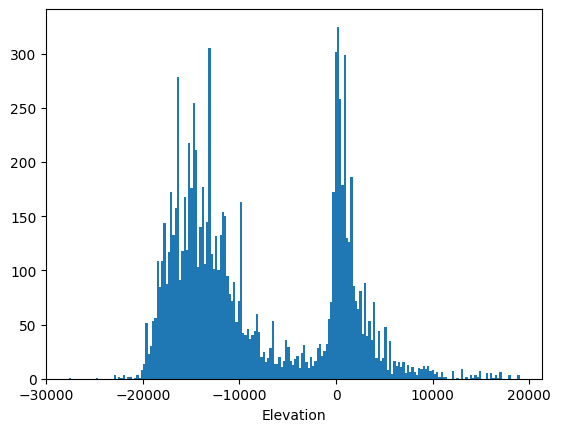

In [ ]:
# 1m = 100cm --> cm/2.54/12 = ft
elev_ft = elevation*(100)/(2.54)/(12)
print(elev_ft)

plt.hist(elev_ft,200)
plt.xlabel("Elevation")
plt.show()

**I see many peaks in the data which represent where there is the most of a certain group (bin) of elevations. So, the highest peaks, at an elevation of about 0 and -15000, represents that a majority of the data is about a 0 foot or -15000 foot elevation. Further, an elevation of 0 could represent the elevation of most of the continents, while the elevation of -15000 could represent the elevation of the sea floor across most of the planet.**

**Question 6.** Find the average and standard deviation of the elevations above sea level. Then find the average and standard deviation of the elevatiosn below sea level.

There are build in python functions to calculate the mean and standard deviation of a data set; you should use these. There are also built in functions that let you extract all the elements in an array that satisfy a certain criteria, which can be helpful for getting all data points above or below sea level.

In [ ]:
above_sea = np.array([a for a in elev_ft if a >= 0])
print("average above sea level: ", np.average(above_sea))
print("std above sea level: ", np.std(above_sea))

below_sea = np.array([a for a in elev_ft if a < 0])
print("average below sea level: ", np.average(below_sea))
print("std below sea level: ", np.std(below_sea))

average above sea level:  2432.1939198389673
std above sea level:  2964.99543653102
average below sea level:  -12261.51325021498
std below sea level:  5191.268345993403


# Working with Atmospheric CO$_2$ data

**Question 7.** Load in the csv file monthly_in_situ_co2_mlo.csv. Look carefully at the file to do this. You will need to skip quite a few rows at the start of the file to cut off all of the header information. The delimiter for this data set is commas (','), and you will need to NOT include the last column of data, since that column is filled with text. The loadtxt command can only deal with numbers.

The file contains a number of data columns explained in the csv file header. The easiest to plot is column 4 for the date and column 8 for the CO$_2$ data. Plot this, along with column 9, which is a smoothed fit to the data that gets rid of the seasonal CO$_2$ cycle.

In [ ]:
from google.colab import files
files.upload()
Atmos_Data = np.loadtxt("monthly_in_situ_co2_mlo.csv", skiprows=(60), usecols=(range(0,10)), delimiter=",", unpack=True)

Saving monthly_in_situ_co2_mlo.csv to monthly_in_situ_co2_mlo (2).csv


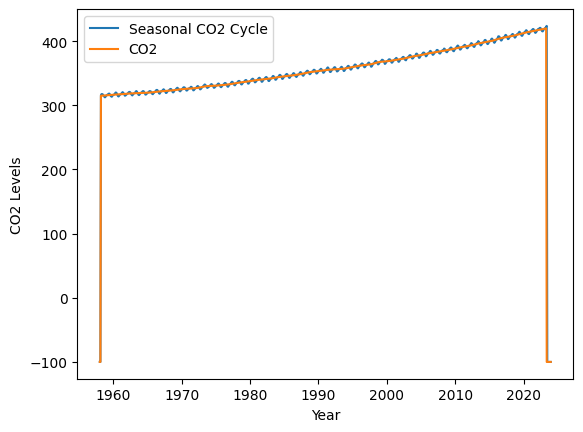

In [ ]:
date = Atmos_Data[3]
seasonal = Atmos_Data[8]
CO2 = Atmos_Data[7]


plt.plot(date,seasonal, date,CO2)
plt.legend(["Seasonal CO2 Cycle", "CO2"])
plt.xlabel("Year")
plt.ylabel("CO2 Levels")

plt.show()

**Question 8.** The CO$_2$ data set uses the value -99 when data is missing, which happens at the start of the data set (in the year 1958), and at the end (since we haven't finished the year 2023 yet). Trim out the first and last years of the data set, so that we don't have anymore missing values, and then plot that.

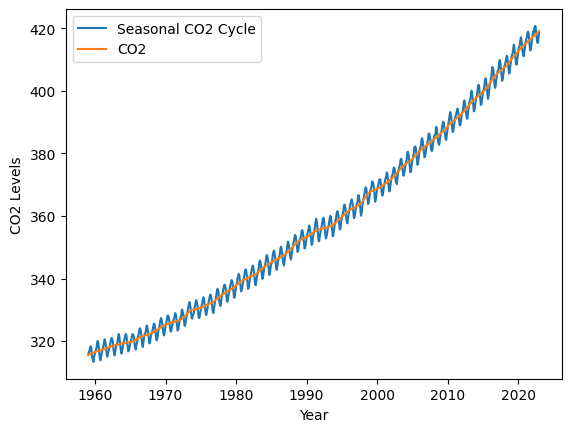

In [ ]:
date2 = date[12:780]

plt.plot(date2,seasonal[12:780], date2,CO2[12:780])
plt.legend(["Seasonal CO2 Cycle", "CO2"])
plt.xlabel("Year")
plt.ylabel("CO2 Levels")

plt.show()

**Question 9.** Now plot just the last year (2022). We can see a clear cycle, that looks like a sine wave. This is a natural seasonal CO$_2$ cycle caused by photosynthesis and respiration. In the summer time trees grow by doing photosynthesis, which draws CO$_2$ out of the atmosphere. In the winter, decay of leaves, dead branches, etc. by respiration puts CO$_2$ back into the atmosphere.

How much does CO$_2$ change over the course of this cycle (in otherwords, the difference between the maximum atmopsheric CO$_2$ and the minimum)?

seasonal max:  420.77
seasonal min:  415.31


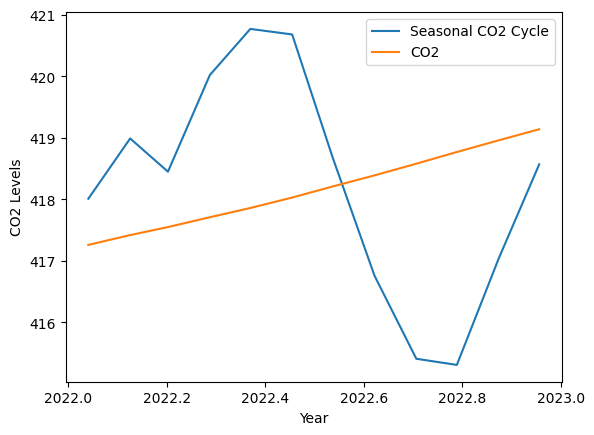

In [ ]:
print("seasonal max: ", max(seasonal[768:780]))
print("seasonal min: ", min(seasonal[768:780]))

date2 = date[768:780]

plt.plot(date2,seasonal[768:780], date2,CO2[768:780])
plt.legend(["Seasonal CO2 Cycle", "CO2"])
plt.xlabel("Year")
plt.ylabel("CO2 Levels")
plt.show()

**Question 10.** Now let's figure out if the amplitude of this seasonal cycle has changed over time. To do this, let's plot the amplitude of the seasonal cycle each year. This will require some thought and data manipulation to do!

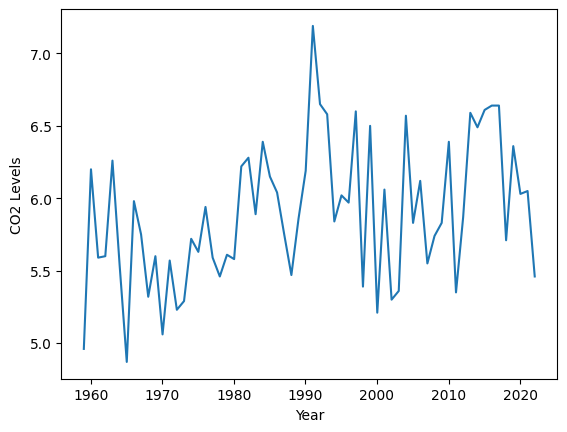

The amplitude increases over time, overall, but at an erratic rate!


In [ ]:
vals = np.array([seasonal[12*n:12*(n+1)] for n in range(int(len(seasonal)/12))])
amp = np.array([(max(m) - min(m)) for m in vals])
years = date[0::12]

plt.plot(years[1:len(vals)-1], amp[1:len(vals)-1])
plt.xlabel("Year")
plt.ylabel("CO2 Levels")

plt.show()
print("The amplitude increases over time, overall, but at an erratic rate!")